[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_02/MFM_ch2_seminar/MFM_ch2_seminar.ipynb)

# MFM_ch2_seminar

Seminar 2 computations: variance ratio and runs test, step by step, Hurst exponent from a variance ratio, homoskedastic vs robust variance ratios on developed and emerging markets, rolling DFA with a per-window wild-bootstrap band, adaptive efficiency of Bitcoin with wild-bootstrap bands, turn of the month with OLS vs HAC errors, Bonferroni and Holm corrections for 15 calendar tests, crisis robustness of the S&P 500 autocorrelation, the BVB, WIG20 and BUX before and after the 2020 FTSE Russell upgrade with a block bootstrap, the bank-tax event study day by day, simulated null distributions of the variance ratio and of the predictive slope, and the exact distribution of the number of runs.

*Modelling Financial Markets (MFM), Chapter 2: Market Efficiency. Author: Daniel Traian Pele.*

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_2'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import io
import os
import re
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from scipy.special import gammaln
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
GROUP_COL = {'Developed': MainBlue, 'Emerging/frontier': IDAred, 'Crypto': Amber, 'FX': Forest}

SEED = 42
TABLE_DIR = '.'


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


## Data

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# nume -> (simbol, eticheta, grup, data de start, zile pe an)
MARKETS = {
    'sp500':  ('GSPC.INDX',     'S&P 500 (US)',          'Developed', '2000-01-01', 252),
    'stoxx':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Developed', '2000-01-01', 252),
    'nikkei': ('N225.INDX',     'Nikkei 225 (Japan)',    'Developed', '2000-01-01', 252),
    'hsi':    ('HSI.INDX',      'Hang Seng (HK)',        'Developed', '2000-01-01', 252),
    'bet':    ('BET',           'BET (Romania)',         'Emerging/frontier', '2000-01-01', 252),
    'wig20':  ('WIG20.INDX',    'WIG20 (Poland)',        'Emerging/frontier', '2000-01-01', 252),
    'bux':    ('BUX.INDX',      'BUX (Hungary)',         'Emerging/frontier', '2000-01-01', 252),
    'px':     ('PX.INDX',       'PX (Czechia)',          'Emerging/frontier', '2000-01-01', 252),
    'xu100':  ('XU100.INDX',    'BIST 100 (Turkey)',     'Emerging/frontier', '2000-01-01', 252),
    'bvsp':   ('BVSP.INDX',     'Bovespa (Brazil)',      'Emerging/frontier', '2000-01-01', 252),
    'mxx':    ('MXX.INDX',      'IPC (Mexico)',          'Emerging/frontier', '2000-01-01', 252),
    'nsei':   ('NSEI.INDX',     'Nifty 50 (India)',      'Emerging/frontier', '2000-01-01', 252),
    'ssec':   ('SSEC.INDX',     'Shanghai (China)',      'Emerging/frontier', '2000-01-01', 252),
    'btc':    ('BTC-USD.CC',    'Bitcoin',               'Crypto', '2014-09-17', 365),
    'eth':    ('ETH-USD.CC',    'Ethereum',              'Crypto', '2016-01-01', 365),
    'eurron': ('REF:EUR',       'EUR/RON (reference rate)', 'FX', '2005-07-01', 252),
}

LABELS = {k: v[1] for k, v in MARKETS.items()}
GROUPS = {k: v[2] for k, v in MARKETS.items()}
PERIODS = {k: v[4] for k, v in MARKETS.items()}

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Cursul oficial de referinta RON (arhive XML anuale BNR)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END):
    """Pretul de inchidere zilnic, curatat dupa conventiile capitolului."""
    symbol, _, group, start0, _ = MARKETS[name]
    start = start or start0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    s = read_market(symbol)['close'].loc[start:end]
    s = s[s > 0].dropna()
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # fara cotatii de weekend
        s = s[s.diff() != 0]                  # fara sarbatori completate cu pretul anterior
    return s.rename(name)


def complete_months(x):
    """Elimina luna finala incompleta (ultima observatie inainte de ultima zi lucratoare a lunii):
    analizele lunare si efectul schimbarii lunii folosesc doar luni complete."""
    last = x.index[-1]
    if last + pd.offsets.BMonthEnd(0) != last:
        x = x[x.index < last.to_period('M').start_time]
    return x


def log_returns(name, start=None, end=END):
    """Randamente log pe calendarul propriu al seriei."""
    return np.log(load_close(name, start, end)).diff().dropna().rename(name)


rets = {k: log_returns(k) for k in MARKETS}
ORDER = list(MARKETS)
for k in ORDER:
    print(f'{LABELS[k]:26s}', rets[k].index[0].date(), '->', rets[k].index[-1].date(), len(rets[k]), 'obs')

S&P 500 (US)               2000-01-04 -> 2026-09-18 6714 obs
Euro Stoxx 50              2000-01-04 -> 2026-09-18 6836 obs
Nikkei 225 (Japan)         2000-01-05 -> 2026-09-18 6545 obs
Hang Seng (HK)             2000-01-04 -> 2026-09-18 6583 obs
BET (Romania)              2000-01-06 -> 2026-09-18 6670 obs
WIG20 (Poland)             2000-01-04 -> 2026-09-18 6685 obs
BUX (Hungary)              2000-01-05 -> 2026-09-18 6666 obs
PX (Czechia)               2000-01-06 -> 2026-09-18 6682 obs
BIST 100 (Turkey)          2000-01-05 -> 2026-09-18 6692 obs
Bovespa (Brazil)           2000-01-04 -> 2026-09-18 6622 obs
IPC (Mexico)               2000-01-04 -> 2026-09-18 6689 obs
Nifty 50 (India)           2000-01-04 -> 2026-09-18 6606 obs
Shanghai (China)           2000-01-05 -> 2026-09-18 6474 obs
Bitcoin                    2014-09-18 -> 2026-09-18 4384 obs
Ethereum                   2016-01-02 -> 2026-09-18 3913 obs
EUR/RON (reference rate)   2005-07-05 -> 2026-09-18 5352 obs


## Efficiency tests

In [4]:
def variance_ratio(r, q):
    """VR(q) cu suprapunere si corectiile de deplasare Lo-MacKinlay (1988).

    Returneaza (VR, z omoscedastic, z* robust la heteroscedasticitate).
    """
    x = np.asarray(r, dtype=float)
    T = len(x)
    mu = x.mean()
    e = x - mu
    var_a = (e ** 2).sum() / (T - 1)
    agg = np.convolve(x, np.ones(q), mode='valid') - q * mu        # sume pe q perioade, suprapuse
    m = q * (T - q + 1) * (1 - q / T)
    var_c = (agg ** 2).sum() / m
    vr = var_c / var_a
    z_homo = (vr - 1) / np.sqrt(2 * (2 * q - 1) * (q - 1) / (3 * q * T))
    den = (e ** 2).sum() ** 2
    theta = 0.0
    for j in range(1, q):
        delta = T * (e[j:] ** 2 * e[:-j] ** 2).sum() / den
        theta += (2 * (q - j) / q) ** 2 * delta
    z_star = np.sqrt(T) * (vr - 1) / np.sqrt(theta)
    return vr, z_homo, z_star


def chow_denning(r, qs=(2, 5, 10, 20)):
    """Testul multiplu Chow-Denning: max |z*(q)|; valoarea p din modulul maxim studentizat (df infinit)."""
    zs = [variance_ratio(r, q)[2] for q in qs]
    zmax = np.max(np.abs(zs))
    p = 1 - (2 * stats.norm.cdf(zmax) - 1) ** len(qs)
    return zmax, p, zs


def runs_test(r):
    """Numarul de secvente de semne (fara zerouri), media si varianta sub ipoteza de independenta."""
    s = np.sign(np.asarray(r, dtype=float))
    s = s[s != 0]
    n1, n2 = (s > 0).sum(), (s < 0).sum()
    n = n1 + n2
    runs = 1 + (s[1:] != s[:-1]).sum()
    mean = 2 * n1 * n2 / n + 1
    var = 2 * n1 * n2 * (2 * n1 * n2 - n) / (n ** 2 * (n - 1))
    z = (runs - mean) / np.sqrt(var)
    return runs, mean, z, 2 * (1 - stats.norm.cdf(abs(z)))


def robust_ljung_box(r, m=10):
    """Q(m) Ljung-Box si Q~(m) cu varianta robusta tau_k = sum e_t^2 e_{t-k}^2 / (sum e_t^2)^2."""
    e = np.asarray(r, dtype=float) - np.mean(r)
    T = len(e)
    s2 = (e ** 2).sum()
    q_lb, q_rob = 0.0, 0.0
    for k in range(1, m + 1):
        rho = (e[k:] * e[:-k]).sum() / s2
        tau = (e[k:] ** 2 * e[:-k] ** 2).sum() / s2 ** 2
        q_lb += T * (T + 2) * rho ** 2 / (T - k)
        q_rob += rho ** 2 / tau
    return q_lb, 1 - stats.chi2.cdf(q_lb, m), q_rob, 1 - stats.chi2.cdf(q_rob, m)


def _rs(x):
    y = np.cumsum(x - x.mean())
    s = x.std(ddof=0)
    return (y.max() - y.min()) / s if s > 0 else np.nan


def expected_rs(n):
    """E[R/S] pentru zgomot i.i.d. (Anis & Lloyd, 1976)."""
    if n <= 340:
        f = np.exp(gammaln((n - 1) / 2) - gammaln(n / 2)) / np.sqrt(np.pi)
    else:
        f = 1 / np.sqrt(n * np.pi / 2)
    i = np.arange(1, n)
    return f * np.sum(np.sqrt((n - i) / i))


def rs_hurst(r, min_n=10, n_sizes=20):
    """H din panta log(R/S) ~ log(n) (Hurst, 1951) si H corectat Anis-Lloyd (panta lui R/S - E[R/S] + 0,5)."""
    x = np.asarray(r, dtype=float)
    T = len(x)
    sizes = np.unique(np.logspace(np.log10(min_n), np.log10(T // 4), n_sizes).astype(int))
    rs, ers = [], []
    for n in sizes:
        k = T // n
        vals = [_rs(x[i * n:(i + 1) * n]) for i in range(k)]
        rs.append(np.nanmean(vals))
        ers.append(expected_rs(n))
    ls, lrs, lers = np.log(sizes), np.log(rs), np.log(ers)
    h = np.polyfit(ls, lrs, 1)[0]
    h_al = 0.5 + np.polyfit(ls, lrs - lers, 1)[0]
    return h, h_al, pd.DataFrame({'n': sizes, 'rs': rs, 'expected_rs': ers})


def lo_modified_rs(r, q=None):
    """Statistica V = Q_T / sqrt(T) a lui Lo (1991); sub H0 (fara memorie lunga) V in [0,809; 1,862] la 95%."""
    x = np.asarray(r, dtype=float)
    T = len(x)
    e = x - x.mean()
    if q is None:                                   # latimea de banda Andrews (1991) pentru AR(1)
        rho = np.corrcoef(e[1:], e[:-1])[0, 1]
        q = int(np.floor((3 * T / 2) ** (1 / 3) * abs(2 * rho / (1 - rho ** 2)) ** (2 / 3)))
    s2 = (e ** 2).mean()
    for j in range(1, q + 1):
        w = 1 - j / (q + 1)
        s2 += 2 * w * (e[j:] * e[:-j]).sum() / T
    y = np.cumsum(e)
    Q = (y.max() - y.min()) / np.sqrt(s2)
    return Q / np.sqrt(T), q


def dfa_hurst(r, min_box=10, n_sizes=18, max_frac=0.25):
    """Exponentul DFA-1: panta log F(n) ~ log n pe profilul cumulat al randamentelor centrate."""
    x = np.asarray(r, dtype=float)
    y = np.cumsum(x - x.mean())
    T = len(y)
    sizes = np.unique(np.logspace(np.log10(min_box), np.log10(int(T * max_frac)), n_sizes).astype(int))
    F = []
    for n in sizes:
        k = T // n
        seg = y[:k * n].reshape(k, n)
        t = np.arange(n)
        A = np.vstack([t, np.ones(n)]).T
        coef, *_ = np.linalg.lstsq(A, seg.T, rcond=None)
        resid = seg.T - A @ coef
        F.append(np.sqrt((resid ** 2).mean()))
    return np.polyfit(np.log(sizes), np.log(F), 1)[0], pd.DataFrame({'n': sizes, 'F': F})


def rolling_stat(r, func, window=500, step=21):
    """Aplica func pe ferestre mobile de `window` observatii, la fiecare `step` observatii."""
    x = r.values
    idx, out = [], []
    for end in range(window, len(x) + 1, step):
        idx.append(r.index[end - 1])
        out.append(func(x[end - window:end]))
    return pd.Series(out, index=idx)

## Helper functions

In [5]:
HERE = '.'

Teal = '#17A2B8'

from scipy.special import comb

CRISES = [('2008-09-01', '2009-06-30'), ('2020-02-15', '2020-06-30')]

DAYS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']

A_RETURNS = np.array([1.0, -0.5, 0.8, 0.3, -1.2, 0.6, 0.9, -0.4])

A_SIGNS = '++-+++--+-++---+-+++'

A4_SIGNS = '+++++-----+++++-----'

def vr_profile(r, qmax=60):
    out = []
    x = np.asarray(r, dtype=float)
    T = len(x)
    e = x - x.mean()
    den = (e ** 2).sum() ** 2
    deltas = np.array([T * (e[j:] ** 2 * e[:-j] ** 2).sum() / den for j in range(1, qmax)])
    for q in range(2, qmax + 1):
        vr = variance_ratio(r, q)[0]
        j = np.arange(1, q)
        theta = np.sum((2 * (q - j) / q) ** 2 * deltas[:q - 1])
        out.append((q, vr, 1.96 * np.sqrt(theta / T)))
    return pd.DataFrame(out, columns=['q', 'VR', 'band']).set_index('q')


def dow_regression(r):
    """Randament zilnic pe variabile dummy pentru zilele saptamanii (fara constanta), erori Newey-West."""
    r = complete_months(r)
    X = pd.get_dummies(r.index.dayofweek).astype(float)
    X.columns = DAYS
    X.index = r.index
    res = sm.OLS(r * 1e4, X).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    # testul egalitatii mediilor (Wald), cu aceleasi erori HAC
    R = np.zeros((4, 5))
    for i in range(4):
        R[i, 0], R[i, i + 1] = 1, -1
    w = res.wald_test(R, scalar=True)
    return res, float(w.pvalue)


def january_regression(r):
    m = np.exp(complete_months(r).groupby(pd.Grouper(freq='ME')).sum()) - 1
    X = sm.add_constant(pd.Series((m.index.month == 1).astype(float), index=m.index, name='January'))
    res = sm.OLS(m * 100, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    return res


def turn_of_month(r):
    """Dummy pentru ultima zi de tranzactionare a lunii si primele trei zile ale lunii urmatoare (Ariel, 1987)."""
    d = pd.DataFrame({'r': complete_months(r) * 1e4})
    ym = d.index.to_period('M')
    rank = d.groupby(ym).cumcount()
    rank_end = d.groupby(ym).cumcount(ascending=False)
    d['tom'] = ((rank < 3) | (rank_end == 0)).astype(float)
    res = sm.OLS(d['r'], sm.add_constant(d['tom'])).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    return res


def calendar_table():
    rows = []
    for k in ['sp500', 'bet', 'stoxx', 'wig20', 'bux']:
        r = rets[k]
        res, p_eq = dow_regression(r)
        jan = january_regression(r)
        tom = turn_of_month(r)
        rows.append(dict(market=LABELS[k], **{f'{d}_bp': res.params[d] for d in DAYS},
                         **{f'{d}_t': res.tvalues[d] for d in DAYS}, dow_equal_p=p_eq,
                         jan_extra_pct=jan.params['January'], jan_t=jan.tvalues['January'],
                         tom_extra_bp=tom.params['tom'], tom_t=tom.tvalues['tom'], tom_p=tom.pvalues['tom']))
    t = pd.DataFrame(rows).set_index('market')
    t.to_csv(os.path.join(TABLE_DIR, 'ch2_calendar_table.csv'), float_format='%.6g')
    return t

## Analysis

In [6]:
def a_vr_by_hand(r=A_RETURNS, q=2):
    """VR(q) fara corectii de deplasare: var(sume pe q zile, suprapuse) / (q * var zilnica)."""
    mu = r.mean()
    var1 = ((r - mu) ** 2).mean()
    sums = np.convolve(r, np.ones(q), mode='valid')
    varq = ((sums - q * mu) ** 2).mean()
    e = r - mu
    rho = [(e[j:] * e[:-j]).sum() / (e ** 2).sum() for j in range(1, q)]
    approx = 1 + 2 * sum((1 - j / q) * rho[j - 1] for j in range(1, q))
    return dict(mean=mu, var1=var1, sums=sums, varq=varq, VR=varq / (q * var1), rho=rho, approx=approx)


def a_runs(signs=A_SIGNS):
    n1, n2 = signs.count('+'), signs.count('-')
    n = n1 + n2
    runs = 1 + sum(signs[i] != signs[i - 1] for i in range(1, n))
    mean = 2 * n1 * n2 / n + 1
    var = 2 * n1 * n2 * (2 * n1 * n2 - n) / (n ** 2 * (n - 1))
    z = (runs - mean) / np.sqrt(var)
    return dict(n1=n1, n2=n2, runs=runs, mean=mean, var=var, z=z, p=2 * (1 - stats.norm.cdf(abs(z))))


def h_from_vr(vr, q):
    """Pentru cresteri autosimilare, VR(q) = q^(2H-1), deci H = 0,5 + ln VR(q) / (2 ln q)."""
    return 0.5 + np.log(vr) / (2 * np.log(q))


def b_vr_table(names):
    rows = []
    for k in names:
        r = log_returns(k) if k != 'bettr' else np.log(read_market('BETTR.INDX')['close']).diff().dropna()
        v2, v5, v10, v20 = (variance_ratio(r, q) for q in (2, 5, 10, 20))
        cd = chow_denning(r)
        rows.append(dict(market=LABELS.get(k, 'BET-TR (Romania)'), N=len(r),
                         VR2=v2[0], z2=v2[1], zstar2=v2[2], VR5=v5[0], z5=v5[1], zstar5=v5[2],
                         VR10=v10[0], z10=v10[1], zstar10=v10[2],
                         VR20=v20[0], z20=v20[1], zstar20=v20[2], CD=cd[0], CD_p=cd[1]))
    return pd.DataFrame(rows).set_index('market')


def b_rolling_dfa(k='sp500', window=500, step=21, n_boot=199, seed=SEED):
    """DFA pe ferestre mobile; banda nula wild bootstrap (semne Rademacher) calculata pentru FIECARE fereastra:
    pastreaza volatilitatea ferestrei (permisa sub RW3) si distruge autocorelatia randamentelor.
    Pentru comparatie: banda i.i.d. Student-t4 (aceeasi pentru toate ferestrele)."""
    rng = np.random.default_rng(seed)
    null = [dfa_hurst(rng.standard_t(4, window))[0] for _ in range(300)]
    lo_t, hi_t = np.percentile(null, [2.5, 97.5])
    r = log_returns(k)
    x = r.values
    rows = []
    for end in range(window, len(x) + 1, step):
        e = x[end - window:end] - x[end - window:end].mean()
        g = np.random.default_rng(seed + end)
        sims = [dfa_hurst(e * g.choice([-1.0, 1.0], window))[0] for _ in range(n_boot)]
        lo, hi = np.percentile(sims, [2.5, 97.5])
        rows.append((r.index[end - 1], dfa_hurst(e)[0], lo, hi))
    d = pd.DataFrame(rows, columns=['date', 'dfa', 'lo', 'hi']).set_index('date')
    d.to_csv(os.path.join(HERE, 'ch2_sem_rolling_dfa.csv'))
    h = d['dfa']
    return dict(lo_t=lo_t, hi_t=hi_t, share_t=float(((h < lo_t) | (h > hi_t)).mean()),
                share_out=float(((h < d['lo']) | (h > d['hi'])).mean()), n=len(d),
                band_lo_mean=float(d['lo'].mean()), band_hi_mean=float(d['hi'].mean()),
                width_min=float((d['hi'] - d['lo']).min()), width_max=float((d['hi'] - d['lo']).max()),
                argwide=(d['hi'] - d['lo']).idxmax().date(), min=h.min(), max=h.max(),
                argmin=h.idxmin().date(), argmax=h.idxmax().date(), mean=h.mean())


def wild_bootstrap_vr_band(x, q=5, n_boot=999, seed=SEED, sims=False):
    """Banda 95% pentru z*(q) sub ipoteza de mers aleator cu heteroscedasticitate: semne Rademacher.
    sims=True intoarce si cele n_boot statistici simulate."""
    rng = np.random.default_rng(seed)
    e = x - x.mean()
    zs = np.array([variance_ratio(e * rng.choice([-1, 1], len(e)), q)[2] for _ in range(n_boot)])
    band = np.percentile(zs, [2.5, 97.5])
    return (band, zs) if sims else band


def b_amh_bitcoin(window=365, step=30, q=5, n_boot=999, seed=SEED):
    """z*(q) pe ferestre de un an (Bitcoin din 1 ian. 2011 pana la 18 sep. 2026); banda wild bootstrap
    cu n_boot replicari in fiecare fereastra (999: cuantilele de 2,5% si 97,5% sunt stabile)."""
    r = log_returns('btc', start='2011-01-01')
    rows = []
    x = r.values
    for end in range(window, len(x) + 1, step):
        w = x[end - window:end]
        z = variance_ratio(w, q)[2]
        lo, hi = wild_bootstrap_vr_band(w, q, n_boot, seed + end)
        rows.append((r.index[end - 1], z, lo, hi, end))
    d = pd.DataFrame(rows, columns=['date', 'zstar', 'lo', 'hi', 'end']).set_index('date')
    d['reject'] = (d['zstar'] < d['lo']) | (d['zstar'] > d['hi'])
    return d


def b_tom_ols_hac(k='sp500'):
    """Efectul turn-of-month: aceeasi regresie cu erori OLS clasice si cu erori HAC (Newey-West, 5 decalaje)."""
    r = complete_months(log_returns(k)) * 1e4
    d = pd.DataFrame({'r': r})
    ym = d.index.to_period('M')
    rank = d.groupby(ym).cumcount()
    rank_end = d.groupby(ym).cumcount(ascending=False)
    d['tom'] = ((rank < 3) | (rank_end == 0)).astype(float)
    X = sm.add_constant(d['tom'])
    ols = sm.OLS(d['r'], X).fit()
    hac = sm.OLS(d['r'], X).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    return dict(N=len(d), share_tom=float(d['tom'].mean()), const=float(ols.params['const']),
                beta=float(ols.params['tom']), se_ols=float(ols.bse['tom']), t_ols=float(ols.tvalues['tom']),
                se_hac=float(hac.bse['tom']), t_hac=float(hac.tvalues['tom']), p_hac=float(hac.pvalues['tom']),
                mean_tom=float(d.loc[d['tom'] == 1, 'r'].mean()), mean_other=float(d.loc[d['tom'] == 0, 'r'].mean()))


def b_calendar_multiple(t):
    """5 piete x 3 efecte (ziua saptamanii, ianuarie, turn-of-month) din calendar_table(); Bonferroni si Holm."""
    rows = []
    for m, row in t.iterrows():
        rows.append((m, 'day of week (equal means)', row['dow_equal_p']))
        rows.append((m, 'January', 2 * (1 - stats.norm.cdf(abs(row['jan_t'])))))
        rows.append((m, 'turn of month', row['tom_p']))
    d = pd.DataFrame(rows, columns=['market', 'effect', 'p'])
    m = len(d)
    d['bonferroni_reject'] = d['p'] < 0.05 / m
    order = d['p'].sort_values().index
    holm = pd.Series(False, index=d.index)
    for i, ix in enumerate(order):
        if d.loc[ix, 'p'] < 0.05 / (m - i):
            holm[ix] = True
        else:
            break
    d['holm_reject'] = holm
    d['raw_reject'] = d['p'] < 0.05
    return d


def _segment_stats(x, keep, q=5):
    """rho1, tau1 si z*(q) Lo-MacKinlay calculate DOAR in segmentele contigue pastrate:
    perechile (t, t-k) si sumele pe q zile care traverseaza o perioada eliminata nu sunt folosite.
    Cu keep = True peste tot, rezultatul coincide cu variance_ratio(x, q)."""
    x = np.asarray(x, dtype=float)
    keep = np.asarray(keep, dtype=bool)
    T = keep.sum()
    mu = x[keep].mean()
    e = np.where(keep, x - mu, 0.0)
    s2 = (e ** 2).sum()

    def pair(k):                          # ambele capete pastrate si toate zilele dintre ele pastrate
        ok = np.convolve(keep.astype(int), np.ones(k + 1, dtype=int), mode='valid') == k + 1
        return ok, e[k:] * ok, e[:-k] * ok
    ok1, a1, b1 = pair(1)
    rho1 = (a1 * b1).sum() / s2
    tau1 = (a1 ** 2 * b1 ** 2).sum() / s2 ** 2
    okq = np.convolve(keep.astype(int), np.ones(q, dtype=int), mode='valid') == q
    agg = (np.convolve(np.where(keep, x, 0.0), np.ones(q), mode='valid') - q * mu)[okq]
    m = q * len(agg) * (1 - q / T)
    vr = ((agg ** 2).sum() / m) / (s2 / (T - 1))
    theta = 0.0
    for j in range(1, q):
        _, a, b = pair(j)
        theta += (2 * (q - j) / q) ** 2 * T * (a ** 2 * b ** 2).sum() / s2 ** 2
    return dict(N=int(T), rho1=rho1, t_iid=rho1 * np.sqrt(T), t_robust=rho1 / np.sqrt(tau1),
                zstar5=np.sqrt(T) * (vr - 1) / np.sqrt(theta), n_pairs=int(ok1.sum()), n_windows=int(okq.sum()))


def b_crisis_robustness():
    """Autocorelatia S&P 500 cu si fara 2008-2009 si 2020; fara crize, statisticile se calculeaza doar in
    segmentele contigue ramase (nicio pereche de zile si nicio suma pe 5 zile nu traverseaza o criza eliminata)."""
    r = log_returns('sp500')
    mask = ~(((r.index >= '2008-09-01') & (r.index <= '2009-06-30')) |
             ((r.index >= '2020-02-15') & (r.index <= '2020-06-30')))
    out = {'all days': _segment_stats(r.values, np.ones(len(r), bool)),
           'without 2008-09 and 2020 crises': _segment_stats(r.values, mask)}
    return pd.DataFrame(out).T


def b_bet_common_period():
    """BET vs BET-TR pe perioada comuna (de la inceputul BET-TR): separa efectul selectiei de cel al dividendelor."""
    tr = np.log(read_market('BETTR.INDX')['close']).diff().dropna()
    b = log_returns('bet')
    out = {}
    for lab, r in [('BET, full sample', b), ('BET, BET-TR period', b.loc[tr.index[0]:tr.index[-1]]),
                   ('BET-TR', tr)]:
        v2 = variance_ratio(r, 2)
        cd = chow_denning(r)
        out[lab] = dict(start=str(r.index[0].date()), N=len(r), rho1=r.autocorr(1), VR2=v2[0], z2=v2[1],
                        zstar2=v2[2], zstar5=variance_ratio(r, 5)[2], CD=cd[0], CD_p=cd[1])
    return out


def rho1_robust(x):
    """rho1 si eroarea standard robusta sqrt(tau1)."""
    x = np.asarray(x, dtype=float)
    e = x - x.mean()
    s2 = (e ** 2).sum()
    return (e[1:] * e[:-1]).sum() / s2, np.sqrt((e[1:] ** 2 * e[:-1] ** 2).sum() / s2 ** 2)


def c_bvb_before_after(split='2020-09-21', years=5, n_boot=999, block=20, seed=SEED, k='bet'):
    """rho1 si z*(5) cu 5 ani inainte si dupa reclasificare; bootstrap pe blocuri mobile, independent in fiecare
    perioada, pentru diferenta rho1(dupa) - rho1(inainte). k = 'bet' (tratat), 'wig20' sau 'bux' (comparatie)."""
    r = log_returns(k)
    s = pd.Timestamp(split)
    before = r.loc[s - pd.DateOffset(years=years):s - pd.Timedelta(days=1)]
    after = r.loc[s:s + pd.DateOffset(years=years)]
    rng = np.random.default_rng(seed)

    def block_boot(x):
        n = len(x)
        starts = rng.integers(0, n - block + 1, int(np.ceil(n / block)))
        return np.concatenate([x[s0:s0 + block] for s0 in starts])[:n]

    def rho1(x):
        return np.corrcoef(x[1:], x[:-1])[0, 1]

    diffs = [rho1(block_boot(after.values)) - rho1(block_boot(before.values)) for _ in range(n_boot)]
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return dict(before=(before.index[0].date(), before.index[-1].date(), len(before), rho1(before.values),
                        variance_ratio(before, 5)[2]),
                after=(after.index[0].date(), after.index[-1].date(), len(after), rho1(after.values),
                       variance_ratio(after, 5)[2]),
                diff=rho1(after.values) - rho1(before.values), ci=(lo, hi),
                se_before=rho1_robust(before.values)[1], se_after=rho1_robust(after.values)[1])


def a2_null(T=1000, n_sim=2000, seed=SEED):
    """z(2) si z*(2) simulate: randamente i.i.d. N(0,1) si randamente GARCH(1,1) (grupare a volatilitatii, RW3 adevarata)."""
    rng = np.random.default_rng(seed)
    z_iid, z_g, zs_g = [], [], []
    for _ in range(n_sim):
        z_iid.append(variance_ratio(rng.standard_normal(T), 2)[1])
        eps = rng.standard_normal(T + 200)
        h, x = 1.0, np.empty(T + 200)
        for t in range(T + 200):                       # h_t = 0.02 + 0.10 x_{t-1}^2 + 0.88 h_{t-1}
            x[t] = np.sqrt(h) * eps[t]
            h = 0.02 + 0.10 * x[t] ** 2 + 0.88 * h
        _, z, zs = variance_ratio(x[200:], 2)
        z_g.append(z)
        zs_g.append(zs)
    z_iid, z_g, zs_g = map(np.array, (z_iid, z_g, zs_g))
    share = lambda z: float((np.abs(z) > 1.96).mean())
    return dict(T=T, n_sim=n_sim, z_iid=z_iid, z_garch=z_g, zstar_garch=zs_g,
                rej_iid=share(z_iid), rej_garch=share(z_g), rej_star_garch=share(zs_g))


def a3_exact(n1=12, n2=8, runs=11):
    """Distributia exacta a numarului de secvente conditionat de n1 si n2 (Wald si Wolfowitz, 1940)."""
    n = n1 + n2
    tot = comb(n, n1)
    pmf = {}
    for r in range(2, n + 1):
        k = r // 2
        if r % 2 == 0:
            pr = 2 * comb(n1 - 1, k - 1) * comb(n2 - 1, k - 1) / tot
        else:
            pr = (comb(n1 - 1, k - 1) * comb(n2 - 1, k) + comb(n1 - 1, k) * comb(n2 - 1, k - 1)) / tot
        if pr > 0:
            pmf[r] = float(pr)
    lo = sum(v for r, v in pmf.items() if r <= runs)
    hi = sum(v for r, v in pmf.items() if r >= runs)
    return dict(pmf=pmf, p_le=lo, p_ge=hi, p_exact=min(1.0, 2 * min(lo, hi)))


def a4_sim(rho=0.98, T=60, corr=-0.9, su=0.17, sv=0.14, n_sim=10000, seed=SEED):
    """Distributia de selectie a pantei predictive sub beta = 0 (sistemul din A4, date anuale ilustrative)."""
    rng = np.random.default_rng(seed)
    b, t = np.empty(n_sim), np.empty(n_sim)
    sx = sv / np.sqrt(1 - rho ** 2)
    for i in range(n_sim):
        z1, z2 = rng.standard_normal((2, T))
        v = sv * z1
        u = su * (corr * z1 + np.sqrt(1 - corr ** 2) * z2)
        x = np.empty(T + 1)
        x[0] = sx * rng.standard_normal()
        for j in range(T):
            x[j + 1] = rho * x[j] + v[j]
        X = np.column_stack([np.ones(T), x[:-1]])
        coef, res, *_ = np.linalg.lstsq(X, u, rcond=None)
        s2 = ((u - X @ coef) ** 2).sum() / (T - 2)
        se = np.sqrt(s2 * np.linalg.inv(X.T @ X)[1, 1])
        b[i], t[i] = coef[1], coef[1] / se
    return dict(beta=b, t=t, mean=float(b.mean()), median=float(np.median(b)),
                rej=float((np.abs(t) > 1.96).mean()), rej_up=float((t > 1.645).mean()))


def ar1_vr(rho, q):
    """VR(q) al unui AR(1) cu rho_k = rho^k."""
    k = np.arange(1, q)
    return 1 + 2 * np.sum((1 - k / q) * rho ** k)


def b1_worked(k='sp500', q=2):
    """Calculul pas cu pas al VR(q), z(q) si z*(q) (Lo si MacKinlay, 1988), randamente in %."""
    x = log_returns(k).values * 100
    T = len(x)
    mu = x.mean()
    e = x - mu
    var_a = (e ** 2).sum() / (T - 1)
    agg = np.convolve(x, np.ones(q), mode='valid') - q * mu
    m = q * (T - q + 1) * (1 - q / T)
    var_c = (agg ** 2).sum() / m
    vr = var_c / var_a
    den = (e ** 2).sum() ** 2
    deltas = [T * (e[j:] ** 2 * e[:-j] ** 2).sum() / den for j in range(1, q)]
    theta = sum((2 * (q - j) / q) ** 2 * deltas[j - 1] for j in range(1, q))
    zstar = np.sqrt(T) * (vr - 1) / np.sqrt(theta)
    z = (vr - 1) / np.sqrt(2 * (2 * q - 1) * (q - 1) / (3 * q * T))
    return dict(T=T, mu=mu, var_a=var_a, m=m, var_c=var_c, VR=vr, delta1=deltas[0], theta=theta,
                z=z, zstar=zstar, p=2 * (1 - stats.norm.cdf(abs(zstar))), n_sums=len(agg))


def b3_window(k='sp500', window=500, box=50):
    """DFA pe o singura fereastra (ultimele `window` randamente): profil, tendinte pe segmente, log F(n) ~ log n."""
    r = log_returns(k)
    w = r.iloc[-window:]
    x = w.values
    y = np.cumsum(x - x.mean())
    slope, tab = dfa_hurst(x)
    fit = np.polyfit(np.log(tab['n']), np.log(tab['F']), 1)
    return dict(start=w.index[0].date(), end=w.index[-1].date(), T=len(x), slope=slope,
                sizes=tab['n'].tolist(), F=tab['F'].tolist(), icpt=float(fit[1]), y=y, box=box, index=w.index,
                n_sizes=len(tab), n_min=int(tab['n'].min()), n_max=int(tab['n'].max()))


def b5_strip(k='sp500', month_end='2026-07'):
    """Zilele de tranzactionare in jurul unei schimbari de luna, cu indicatorul TOM si randamentul in bp."""
    r = complete_months(log_returns(k)) * 1e4
    d = pd.DataFrame({'r': r})
    ym = d.index.to_period('M')
    rank = d.groupby(ym).cumcount()
    rank_end = d.groupby(ym).cumcount(ascending=False)
    d['tom'] = ((rank < 3) | (rank_end == 0)).astype(int)
    p = pd.Period(month_end, 'M')
    sel = pd.concat([d[ym == p].iloc[-5:], d[ym == p + 1].iloc[:5]])
    return sel


def b9_event_path(event='2018-12-19', est=(-250, -11), days=(-10, 5)):
    """AR zilnice, erorile standard de predictie si CAR pentru TLV, BRD si portofoliul egal ponderat."""
    px = pd.concat({'TLV': read_market('TLV.RO')['adjusted_close'], 'BRD': read_market('BRD.RO')['adjusted_close'],
                    'BET': read_market('BET')['close']}, axis=1).dropna()        # join pe preturi, zile comune
    px = px[px.index.dayofweek < 5]
    r = np.log(px).diff().dropna()
    t0 = r.index.get_loc(pd.Timestamp(event))
    E = r.iloc[t0 + est[0]:t0 + est[1] + 1]
    W = r.iloc[t0 + days[0]:t0 + days[1] + 1]
    mu_m, var_m, T0 = E['BET'].mean(), E['BET'].var(ddof=1), len(E)
    out = {}
    for k in ['TLV', 'BRD', 'PORT']:
        yE = E[['TLV', 'BRD']].mean(axis=1) if k == 'PORT' else E[k]
        yW = W[['TLV', 'BRD']].mean(axis=1) if k == 'PORT' else W[k]
        f = sm.OLS(yE, sm.add_constant(E['BET'])).fit()
        ar = yW - f.params['const'] - f.params['BET'] * W['BET']
        se = np.sqrt(f.mse_resid * (1 + 1 / T0 + (W['BET'] - mu_m) ** 2 / ((T0 - 1) * var_m)))
        out[k] = pd.DataFrame({'day': np.arange(days[0], days[1] + 1), 'AR': ar.values, 'se': se.values},
                              index=W.index)
    return out


def c1_rolling(keys=('bet', 'wig20', 'bux'), window=250, start='2014-01-01'):
    """rho1 pe ferestre mobile de `window` zile, cu eroarea standard robusta."""
    out = {}
    for k in keys:
        x = log_returns(k, start=start)
        vals = [rho1_robust(x.values[i - window:i]) for i in range(window, len(x) + 1)]
        out[k] = pd.DataFrame(vals, columns=['rho1', 'se'], index=x.index[window - 1:])
    return out


def fig_b2(t2, b1, b2c):
    """B2: z(2) clasic vs z*(2) robust pe piete si valoarea p Chow-Denning (test comun pe q = 2, 5, 10, 20)."""
    rows = [(LABELS['bet'].split(' (')[0] + ', 2000-2026', b1.loc[LABELS['bet'], 'z2'], b1.loc[LABELS['bet'], 'zstar2'],
             b1.loc[LABELS['bet'], 'CD_p']),
            ('BET, BET-TR period', b2c['BET, BET-TR period']['z2'], b2c['BET, BET-TR period']['zstar2'],
             b2c['BET, BET-TR period']['CD_p'])]
    rows += [(m.split(' (')[0], r['z2'], r['zstar2'], r['CD_p']) for m, r in t2.iterrows()]
    d = pd.DataFrame(rows, columns=['m', 'z2', 'zs2', 'cdp']).iloc[::-1]
    y = np.arange(len(d))
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.4), sharey=True)
    ax = axes[0]
    ax.barh(y + 0.2, d['z2'], 0.38, color=MainBlue, alpha=0.4, label='Classical z(2), RW1')
    ax.barh(y - 0.2, d['zs2'], 0.38, color=MainBlue, label='Robust z*(2), RW3')
    for v in (-1.96, 1.96):
        ax.axvline(v, color=Gray, ls='--', lw=0.7)
    ax.axvline(0, color=Gray, lw=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(d['m'], fontsize=7.5)
    ax.set_title('One horizon, q = 2 (dashed: 1.96)', fontsize=8.5, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.12)
    ax = axes[1]
    ax.barh(y, d['cdp'], 0.5, color=[IDAred if p < 0.05 else Forest for p in d['cdp']])
    ax.axvline(0.05, color=Purple, ls='--', lw=1.0)
    ax.set_xscale('log')
    ax.set_xlabel('Chow-Denning p-value (log scale)')
    ax.set_title('Joint test over q = 2, 5, 10, 20', fontsize=8.5, loc='left')
    ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=IDAred, label='p < 0.05'),
                       plt.Rectangle((0, 0), 1, 1, color=Forest, label='p >= 0.05'),
                       plt.Line2D([], [], color=Purple, ls='--', label='5%')],
              loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
    plt.tight_layout()
    save_fig('ch2_sem_b2')


def setup_check():
    """Verificarea datelor: primele inchideri si randamente S&P 500 si numarul de randamente."""
    p = load_close('sp500')
    r = np.log(p).diff()
    rows = [dict(date=i.date(), close=float(p.loc[i]), r=float(r.loc[i]) if i != p.index[0] else None)
            for i in p.index[:4]]
    return dict(rows=rows, N_sp=int(r.notna().sum()), N_bet=len(log_returns('bet')), first=p.index[0].date(),
                last=p.index[-1].date())


def fig_sem_data():
    """Preturile (scara log) si randamentele log zilnice pentru S&P 500 si BET, 2000 -- 18 sep. 2026."""
    fig, axes = plt.subplots(2, 2, figsize=(8.6, 3.6), sharex=True)
    for j, (k, c) in enumerate([('sp500', MainBlue), ('bet', IDAred)]):
        p = load_close(k)
        r = np.log(p).diff().dropna() * 100
        axes[0, j].plot(p.index, p.values, color=c, lw=0.9)
        axes[0, j].set_yscale('log')
        axes[0, j].set_title(f'{LABELS[k]}: close (log scale)', fontsize=8.5, loc='left', color=c)
        axes[1, j].plot(r.index, r.values, color=c, lw=0.4)
        axes[1, j].set_title('Daily log return (%)', fontsize=8.5, loc='left', color=c)
        for a, b in CRISES:
            for i in range(2):
                axes[i, j].axvspan(pd.Timestamp(a), pd.Timestamp(b), color=Amber, alpha=0.25, lw=0)
    h = [plt.Line2D([], [], color=MainBlue, lw=1.2, label='S&P 500 (US)'),
         plt.Line2D([], [], color=IDAred, lw=1.2, label='BET (Romania)'),
         plt.Rectangle((0, 0), 1, 1, color=Amber, alpha=0.25, label='Sep 2008 - Jun 2009 and Feb - Jun 2020')]
    fig.legend(handles=h, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False)
    plt.tight_layout()
    save_fig('ch2_sem_data')


def fig_a1(a1):
    """A1: cele opt randamente si sumele suprapuse pe doua zile."""
    r = A_RETURNS
    t = np.arange(1, len(r) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 2.8))
    ax = axes[0]
    ax.bar(t, r, color=[Forest if v > 0 else IDAred for v in r], width=0.55)
    ax.axhline(a1['mean'], color=MainBlue, ls='--', lw=0.9, label=r'Mean $\hat\mu$ = %.4f' % a1['mean'])
    ax.axhline(0, color=Gray, lw=0.5)
    for i, v in zip(t, r):
        ax.text(i, v + (0.06 if v > 0 else -0.06), f'{v:+.1f}', ha='center', va='bottom' if v > 0 else 'top',
                fontsize=7.5, color='black')
    ax.set_ylim(-1.7, 1.4)
    ax.set_xticks(t)
    ax.set_xlabel('Day t')
    ax.set_ylabel('Return (%)')
    ax.set_title('Eight daily returns', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=1, y=-0.3)
    ax = axes[1]
    s2 = a1['sums']
    ts = np.arange(2, len(r) + 1)
    ax.bar(ts, s2, color=Purple, width=0.55, label=r'$s_t = r_{t-1} + r_t$')
    ax.axhline(2 * a1['mean'], color=MainBlue, ls='--', lw=0.9, label=r'$2\hat\mu$ = %.3f' % (2 * a1['mean']))
    ax.axhline(0, color=Gray, lw=0.5)
    for i, v in zip(ts, s2):
        ax.text(i, v + (0.06 if v > 0 else -0.06), f'{v:+.1f}', ha='center', va='bottom' if v > 0 else 'top',
                fontsize=7.5, color='black')
    ax.set_ylim(-1.4, 1.9)
    ax.set_xticks(ts)
    ax.set_xticklabels([f'{i - 1}+{i}' for i in ts])
    ax.set_xlabel('Days summed')
    ax.set_title(r'Seven overlapping two-day sums: $\widehat{VR}(2)$ = %.3f' % a1['VR'], fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.3)
    plt.tight_layout()
    save_fig('ch2_sem_a1')


def fig_a2(sim):
    """A2: perechile de covariante pentru q = 3 si distributia lui z(2) sub i.i.d. si sub GARCH."""
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.0), gridspec_kw={'width_ratios': [1, 2.3]})
    ax = axes[0]
    col = {0: MainBlue, 1: Forest, 2: Amber}
    for i in range(3):
        for j in range(3):
            lag = abs(i - j)
            ax.add_patch(plt.Rectangle((j, 2 - i), 0.95, 0.95, color=col[lag], alpha=0.85))
            ax.text(j + 0.47, 2 - i + 0.47, rf'$\gamma_{lag}$', ha='center', va='center', color='white', fontsize=11)
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_xticks([0.47, 1.47, 2.47])
    ax.set_xticklabels([r'$r_t$', r'$r_{t-1}$', r'$r_{t-2}$'])
    ax.set_yticks([0.47, 1.47, 2.47])
    ax.set_yticklabels([r'$r_{t-2}$', r'$r_{t-1}$', r'$r_t$'])
    ax.set_title(r'Var$(r_t + r_{t-1} + r_{t-2})$: 3 $\gamma_0$ + 4 $\gamma_1$ + 2 $\gamma_2$', fontsize=8.5, loc='left')
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax = axes[1]
    bins = np.linspace(-6, 6, 61)
    ax.hist(sim['z_iid'], bins=bins, density=True, color=MainBlue, alpha=0.55,
            label=f"z(2), i.i.d. returns: |z| > 1.96 in {100 * sim['rej_iid']:.1f}%")
    ax.hist(sim['z_garch'], bins=bins, density=True, histtype='step', color=IDAred, lw=1.4,
            label=f"z(2), GARCH returns: {100 * sim['rej_garch']:.1f}%")
    ax.hist(sim['zstar_garch'], bins=bins, density=True, histtype='step', color=Forest, lw=1.4,
            label=f"z*(2), GARCH returns: {100 * sim['rej_star_garch']:.1f}%")
    g = np.linspace(-6, 6, 300)
    ax.plot(g, stats.norm.pdf(g), color='black', lw=1.0, label='N(0,1) density')
    for v in (-1.96, 1.96):
        ax.axvline(v, color=Gray, ls='--', lw=0.7)
    ax.set_xlabel('Statistic')
    ax.set_title(f"Null distributions, T = {sim['T']}, {sim['n_sim']} simulations", fontsize=8.5, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.22)
    plt.tight_layout()
    save_fig('ch2_sem_a2')


def fig_a3(a3, ex):
    """A3: semnele numerotate cu granitele secventelor si distributia exacta a numarului de secvente."""
    fig, axes = plt.subplots(2, 1, figsize=(8.6, 3.4), gridspec_kw={'height_ratios': [1, 2.2]})
    ax = axes[0]
    run = 1
    for i, c in enumerate(A_SIGNS):
        if i > 0 and c != A_SIGNS[i - 1]:
            run += 1
            ax.axvline(i - 0.5, color='black', lw=1.2)
        ax.add_patch(plt.Rectangle((i - 0.45, 0), 0.9, 1, color=Forest if c == '+' else IDAred, alpha=0.85))
        ax.text(i, 0.5, '+' if c == '+' else '−', ha='center', va='center', color='white', fontsize=12)
        ax.text(i, -0.35, str(i + 1), ha='center', va='center', fontsize=7, color='black')
    ax.set_xlim(-0.6, len(A_SIGNS) - 0.4)
    ax.set_ylim(-0.6, 1.1)
    ax.axis('off')
    ax.set_title(f"Signs of 20 returns: n1 = {ex['n1']} plus, n2 = {ex['n2']} minus, R = {ex['runs']} runs "
                 "(black lines: run boundaries)", fontsize=8.5, loc='left')
    ax = axes[1]
    rr = np.array(list(a3['pmf'].keys()))
    pp = np.array(list(a3['pmf'].values()))
    ax.bar(rr, pp, color=[IDAred if v == ex['runs'] else MainBlue for v in rr], width=0.7,
           label='Exact P(R = r | n1, n2)')
    g = np.linspace(rr.min(), rr.max(), 200)
    ax.plot(g, stats.norm.pdf(g, ex['mean'], np.sqrt(ex['var'])), color=Amber, lw=1.3,
            label=f"Normal approximation, mean {ex['mean']:.1f}, SD {np.sqrt(ex['var']):.2f}")
    ax.set_xlabel('Number of runs R')
    ax.set_ylabel('Probability')
    ax.set_xticks(rr)
    hs, ls = ax.get_legend_handles_labels()
    hs.append(plt.Rectangle((0, 0), 1, 1, color=IDAred))
    ls.append(f"Observed R = {ex['runs']}: exact P(R >= {ex['runs']}) = {a3['p_ge']:.3f}")
    ax.legend(hs, ls, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=3, frameon=False)
    plt.tight_layout()
    save_fig('ch2_sem_a3')


def fig_a4(sim, bias):
    """A4: distributia pantei OLS sub beta = 0, T = 60, rho = 0,98, corr(u, v) = -0,9."""
    fig, ax = plt.subplots(figsize=(8.6, 2.9))
    ax.hist(sim['beta'], bins=80, density=True, color=MainBlue, alpha=0.6, label=r'Simulated $\hat\beta$ (10,000 samples)')
    ax.axvline(0, color='black', lw=1.0, label=r'True $\beta = 0$')
    ax.axvline(sim['mean'], color=IDAred, lw=1.4, label=r'Monte Carlo mean of $\hat\beta$ = %.3f' % sim['mean'])
    ax.axvline(bias, color=Forest, ls='--', lw=1.4, label=r'Approximate bias $-\phi(1 + 3\rho)/T$ = %.3f' % bias)
    ax.set_xlabel(r'Estimated predictive slope $\hat\beta$')
    ax.set_title(r'Nominal 5%% $t$-test under $\beta = 0$ rejects in %.1f%% of samples (one-sided, $\beta > 0$: %.1f%%)'
                 % (100 * sim['rej'], 100 * sim['rej_up']), fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.25)
    plt.tight_layout()
    save_fig('ch2_sem_a4')


def fig_a56(rho_pos, rho_neg, h_bet, h_sp, qmax=500):
    """A5-A6: VR(q) si H(q) implicat pentru doua AR(1) (memorie scurta) si valorile empirice la q = 20."""
    q = np.unique(np.logspace(np.log10(2), np.log10(qmax), 80).astype(int))
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.0))
    for rho, c, lab in [(rho_pos, IDAred, r'AR(1), $\rho_1$ = %.3f (BET)' % rho_pos),
                        (rho_neg, MainBlue, r'AR(1), $\rho_1$ = %.1f' % rho_neg)]:
        vr = np.array([ar1_vr(rho, k) for k in q])
        axes[0].plot(q, vr, color=c, lw=1.3, label=lab)
        axes[1].plot(q, 0.5 + np.log(vr) / (2 * np.log(q)), color=c, lw=1.3, label=lab)
        axes[0].axhline((1 + rho) / (1 - rho), color=c, ls=':', lw=0.8)
    axes[1].scatter([20], [h_bet], color=IDAred, marker='D', s=30, zorder=3, label='BET, implied H(20) = %.3f' % h_bet)
    axes[1].scatter([20], [h_sp], color=MainBlue, marker='D', s=30, zorder=3,
                    label='S&P 500, implied H(20) = %.3f' % h_sp)
    for ax in axes:
        ax.set_xscale('log')
        ax.set_xlabel('Horizon q (days, log scale)')
    axes[0].axhline(1, color=Gray, lw=0.6)
    axes[1].axhline(0.5, color=Gray, lw=0.6)
    axes[0].set_title('VR(q): dotted line = limit (1 + rho)/(1 - rho)', fontsize=8.5, loc='left')
    axes[1].set_title('Implied H(q) = 0.5 + ln VR(q) / (2 ln q) tends to 0.5', fontsize=8.5, loc='left')
    h, l = axes[1].get_legend_handles_labels()
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False)
    plt.tight_layout()
    save_fig('ch2_sem_a56')


def fig_b1(t):
    """B1: profilul VR(q) cu banda robusta si z(q) clasic vs z*(q) robust, S&P 500 si BET."""
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.1))
    ax = axes[0]
    for k, c in [('sp500', MainBlue), ('bet', IDAred)]:
        vp = vr_profile(log_returns(k))
        ax.fill_between(vp.index, 1 - vp['band'], 1 + vp['band'], color=c, alpha=0.12, lw=0)
        ax.plot(vp.index, vp['VR'], color=c, lw=1.3, label=LABELS[k])
    ax.axhline(1, color=Gray, lw=0.6)
    ax.set_xlabel('Horizon q (days)')
    ax.set_ylabel(r'$\widehat{VR}(q)$')
    ax.set_title('VR(q) with robust 95% bands around 1 (shaded)', fontsize=8.5, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.22)
    ax = axes[1]
    qs = [2, 5, 10, 20]
    xpos = np.arange(len(qs))
    w = 0.2
    for i, (m, c) in enumerate([(LABELS['sp500'], MainBlue), (LABELS['bet'], IDAred)]):
        z = [t.loc[m, f'z{q}'] for q in qs]
        zs = [t.loc[m, f'zstar{q}'] for q in qs]
        ax.bar(xpos + (2 * i - 1.5) * w, z, w, color=c, alpha=0.35, label=f"{m.split(' (')[0]}: classical z(q)")
        ax.bar(xpos + (2 * i - 0.5) * w, zs, w, color=c, label=f"{m.split(' (')[0]}: robust z*(q)")
    for v in (-1.96, 1.96):
        ax.axhline(v, color=Gray, ls='--', lw=0.7)
    for v in (-2.49, 2.49):
        ax.axhline(v, color=Purple, ls=':', lw=1.0)
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xticks(xpos)
    ax.set_xticklabels([f'q = {q}' for q in qs])
    ax.set_title('Dashed: single-test 5% value 1.96; dotted: Chow-Denning 2.49', fontsize=8.5, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    plt.tight_layout()
    save_fig('ch2_sem_b1')


def fig_b3_window(w):
    """B3: DFA pe o fereastra de 500 de zile: profilul cu tendintele pe segmente si dreapta log F(n) ~ log n."""
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.0))
    ax = axes[0]
    y, n = w['y'], w['box']
    t = np.arange(len(y))
    ax.plot(w['index'], y, color=MainBlue, lw=0.9, label=r'Profile $y_k = \sum_{i \leq k} (r_i - \bar r)$')
    for b in range(len(y) // n):
        seg = slice(b * n, (b + 1) * n)
        c = np.polyfit(t[seg], y[seg], 1)
        ax.plot(w['index'][seg], np.polyval(c, t[seg]), color=IDAred, lw=1.2,
                label=f'Linear trend in each box of n = {n} days' if b == 0 else None)
        ax.axvline(w['index'][b * n], color=Gray, lw=0.4, ls=':')
    ax.set_title(f"S&P 500, {w['start']} to {w['end']} ({w['T']} returns)", fontsize=8.5, loc='left')
    ax.tick_params(axis='x', labelsize=7)
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    ax = axes[1]
    ln, lf = np.log(w['sizes']), np.log(w['F'])
    ax.scatter(ln, lf, color=MainBlue, s=18, zorder=3, label=f"log F(n), {w['n_sizes']} box sizes from {w['n_min']} to {w['n_max']}")
    ax.plot(ln, w['icpt'] + w['slope'] * ln, color=IDAred, lw=1.2, label=r'OLS slope $\hat\alpha_{DFA}$ = %.3f' % w['slope'])
    ax.plot(ln, w['icpt'] + 0.5 * (ln - ln[0]) + w['slope'] * ln[0], color=Forest, ls='--', lw=1.0,
            label='Slope 0.5 (no memory), same start')
    ax.set_xlabel('log n (box length)')
    ax.set_ylabel('log F(n)')
    ax.set_title('Fluctuation function and its slope', fontsize=8.5, loc='left')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    plt.tight_layout()
    save_fig('ch2_sem_b3_window')


def fig_b3_rolling(d, lo_t, hi_t):
    """B3: exponentul DFA al S&P 500 pe ferestre mobile, cu banda wild bootstrap pe fereastra si banda fixa t4."""
    fig, ax = plt.subplots(figsize=(8.6, 3.0))
    ax.fill_between(d.index, d['lo'], d['hi'], color=LightGray, alpha=0.9, lw=0,
                    label='Sign-flip 95% band, recomputed in each window (199 draws)')
    ax.plot(d.index, d['dfa'], color=MainBlue, lw=1.1, label=r'S&P 500 $\hat\alpha_{DFA}$, 500-day windows, step 21')
    ax.axhline(lo_t, color=Purple, ls='--', lw=1.0, label=f'Fixed i.i.d. Student-t4 band [{lo_t:.3f}, {hi_t:.3f}]')
    ax.axhline(hi_t, color=Purple, ls='--', lw=1.0)
    ax.axhline(0.5, color=Gray, lw=0.6)
    out = d[(d['dfa'] < d['lo']) | (d['dfa'] > d['hi'])]
    ax.scatter(out.index, out['dfa'], color=IDAred, s=16, zorder=3, label='Outside its own band')
    ax.set_ylabel(r'$\hat\alpha_{DFA}$')
    legend_outside_bottom(ax, ncol=2, y=-0.12)
    plt.tight_layout()
    save_fig('ch2_sem_b3_rolling')


def fig_amh_btc(d, sims=None, z0=None, date0=None):
    """B4: z*(5) de Bitcoin pe ferestre de 365 de zile, banda wild bootstrap pe fereastra si +-1,96;
    in dreapta, distributia bootstrap intr-o fereastra semnalata."""
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.1), gridspec_kw={'width_ratios': [2.6, 1]})
    ax = axes[0]
    ax.fill_between(d.index, d['lo'], d['hi'], color=LightGray, alpha=0.9, lw=0,
                    label='Sign-flip 95% band per window (999 draws)')
    ax.plot(d.index, d['zstar'], color=Amber, lw=1.1, label=r'Bitcoin $z^*(5)$, 365-day windows, step 30')
    for x in (-1.96, 1.96):
        ax.axhline(x, color=Purple, ls='--', lw=0.9)
    ax.plot([], [], color=Purple, ls='--', lw=0.9, label=r'$\pm 1.96$')
    r = d[d['reject']]
    ax.scatter(r.index, r['zstar'], color=IDAred, zorder=3, s=22, label='Outside its band')
    for i, row in r.iterrows():
        ax.annotate(str(i.date()), (i, row['zstar']), xytext=(4, 4), textcoords='offset points', fontsize=7,
                    color=IDAred)
    ax.set_ylabel(r'$z^*(5)$')
    legend_outside_bottom(ax, ncol=2, y=-0.12)
    ax = axes[1]
    if sims is not None:
        ax.hist(sims, bins=40, color=MainBlue, alpha=0.6, density=True, label='Bootstrap z*(5)')
        lo, hi = np.percentile(sims, [2.5, 97.5])
        for v in (lo, hi):
            ax.axvline(v, color=Gray, ls='--', lw=0.8)
        ax.axvline(z0, color=IDAred, lw=1.4, label=f'Observed {z0:.2f}')
        ax.set_title(f'Window ending {date0}', fontsize=8.5, loc='left')
        legend_outside_bottom(ax, ncol=1, y=-0.12)
    plt.tight_layout()
    save_fig('ch2_sem_amh_btc')


def fig_b5(strip, res):
    """B5: zilele TOM la o schimbare de luna si efectul TOM cu intervale OLS si HAC."""
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 2.9), gridspec_kw={'width_ratios': [1.5, 1]})
    ax = axes[0]
    x = np.arange(len(strip))
    ax.bar(x, strip['r'], color=[Orange if t else MainBlue for t in strip['tom']], width=0.65)
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([d.strftime('%d %b') for d in strip.index], rotation=45, fontsize=7)
    ax.set_ylabel('S&P 500 log return (bp)')
    ax.set_title('Month boundary July/August 2026', fontsize=8.5, loc='left')
    ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=Orange, label='TOM = 1 (last day, first three days)'),
                       plt.Rectangle((0, 0), 1, 1, color=MainBlue, label='TOM = 0')],
              loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=False)
    ax = axes[1]
    for i, (k, c) in enumerate([('sp500', MainBlue), ('bet', IDAred)]):
        b = res[k]
        ax.errorbar(i - 0.1, b['beta'], yerr=1.96 * b['se_ols'], fmt='o', color=c, capsize=3, alpha=0.5)
        ax.errorbar(i + 0.1, b['beta'], yerr=1.96 * b['se_hac'], fmt='s', color=c, capsize=3)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['S&P 500', 'BET'])
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylabel(r'$\hat b$ (bp per TOM day)')
    ax.set_title('TOM coefficient, 95% intervals', fontsize=8.5, loc='left')
    ax.legend(handles=[plt.Line2D([], [], marker='o', ls='', color='black', alpha=0.5, label='OLS'),
                       plt.Line2D([], [], marker='s', ls='', color='black', label='HAC, 5 lags')],
              loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
    plt.tight_layout()
    save_fig('ch2_sem_b5')


def fig_b6(cm):
    """B6: valorile p ordonate (scara log) cu pragurile brut, Bonferroni si Holm."""
    d = cm.sort_values('p').reset_index(drop=True)
    m = len(d)
    j = np.arange(1, m + 1)
    fig, ax = plt.subplots(figsize=(8.6, 3.0))
    ax.axhline(0.05, color=Amber, ls='--', lw=1.0, label='Raw 5%')
    ax.axhline(0.05 / m, color=IDAred, ls='--', lw=1.0, label=f'Bonferroni 0.05/{m}')
    ax.step(j, 0.05 / (m - j + 1), where='mid', color=Forest, lw=1.2, label='Holm threshold 0.05/(M - j + 1)')
    col = [IDAred if h else (Amber if rr else MainBlue) for h, rr in zip(d['holm_reject'], d['raw_reject'])]
    ax.scatter(j, d['p'], color=col, s=30, zorder=3)
    for i, row in d.iterrows():
        lab = f"{row['market'].split(' (')[0]}, {row['effect'].replace(' (equal means)', '')}"
        ax.annotate(lab, (i + 1, row['p']), xytext=(3, -3 if i % 2 else 5), textcoords='offset points', fontsize=6,
                    rotation=30, color='black')
    first_fail = int((~d['holm_reject']).idxmax()) + 1
    ax.axvline(first_fail, color=Purple, ls=':', lw=1.0, label=f'Holm stops at rank {first_fail}')
    ax.set_yscale('log')
    ax.set_xticks(j)
    ax.set_xlabel('Rank j of the p-value')
    ax.set_ylabel('p-value (log scale)')
    ax.set_ylim(d['p'].min() / 5, 40)
    hs, ls = ax.get_legend_handles_labels()
    hs += [plt.Line2D([], [], marker='o', ls='', color=IDAred), plt.Line2D([], [], marker='o', ls='', color=Amber),
           plt.Line2D([], [], marker='o', ls='', color=MainBlue)]
    ls += ['Rejected by Holm', 'Rejected only without correction', 'Not rejected']
    ax.legend(hs, ls, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4, frameon=False)
    plt.tight_layout()
    save_fig('ch2_sem_b6')


def fig_b7(b7):
    """B7: randamentele S&P 500 cu crizele eliminate si rho1 cu intervale robuste in cele doua selectii."""
    r = log_returns('sp500') * 100
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 2.9), gridspec_kw={'width_ratios': [2.2, 1]})
    ax = axes[0]
    ax.plot(r.index, r.values, color=MainBlue, lw=0.4)
    for a, b in CRISES:
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=IDAred, alpha=0.2, lw=0)
    ax.set_ylabel('Daily log return (%)')
    ax.set_title('S&P 500; shaded: days removed (Sep 2008 - Jun 2009, 15 Feb - 30 Jun 2020)', fontsize=8.5, loc='left')
    ax = axes[1]
    for i, (lab, c) in enumerate([('all days', MainBlue), ('without 2008-09 and 2020 crises', Forest)]):
        b = b7[lab]
        se = b['rho1'] / b['t_robust']
        ax.errorbar(i, b['rho1'], yerr=1.96 * se, fmt='o', color=c, capsize=4)
        ax.text(i + 0.08, b['rho1'], f"{b['rho1']:.3f}\nz*(5) = {b['zstar5']:.2f}", fontsize=7, va='center',
                color='black')
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['All days', 'Without crises'])
    ax.set_xlim(-0.4, 1.7)
    ax.set_ylabel(r'$\hat\rho_1$, robust 95% interval')
    plt.tight_layout()
    save_fig('ch2_sem_b7')


def fig_b9(ev):
    """B9: AR zilnice (+-1,96 erori standard de predictie la portofoliu) si CAR din ziua 0."""
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.0))
    ax = axes[0]
    w = 0.27
    for i, (k, c) in enumerate([('TLV', MainBlue), ('BRD', Forest), ('PORT', IDAred)]):
        d = ev[k]
        ax.bar(d['day'] + (i - 1) * w, 100 * d['AR'], w, color=c,
               label={'TLV': 'Banca Transilvania', 'BRD': 'BRD', 'PORT': 'Equal-weighted portfolio'}[k])
    p = ev['PORT']
    ax.fill_between(p['day'], -196 * p['se'], 196 * p['se'], color=LightGray, alpha=0.7, lw=0, step='mid',
                    label=r'Portfolio $\pm 1.96$ prediction-error SE', zorder=0)
    ax.axvline(0, color=Gray, ls='--', lw=0.7)
    ax.set_xlabel('Event day (0 = 19 Dec 2018)')
    ax.set_ylabel('Abnormal return (%)')
    ax.set_title('Daily abnormal returns', fontsize=8.5, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    ax = axes[1]
    for k, c in [('TLV', MainBlue), ('BRD', Forest), ('PORT', IDAred)]:
        d = ev[k][ev[k]['day'] >= 0]
        ax.plot(d['day'], 100 * d['AR'].cumsum(), color=c, marker='o', ms=3, lw=1.2)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xlabel('Event day')
    ax.set_ylabel('CAR from day 0 (%)')
    ax.set_title('Cumulative abnormal return, days 0 to +5', fontsize=8.5, loc='left')
    plt.tight_layout()
    save_fig('ch2_sem_b9')


def fig_c1(roll, res, split='2020-09-21', announce='2019-09-26'):
    """C1: rho1 pe 250 de zile cu intervale robuste (BET, WIG20, BUX) si schimbarea pre/post cu bootstrap pe blocuri."""
    fig = plt.figure(figsize=(8.6, 3.6))
    gs = fig.add_gridspec(3, 2, width_ratios=[2.3, 1])
    cols = {'bet': IDAred, 'wig20': MainBlue, 'bux': Forest}
    end = pd.Timestamp(res['bet']['after'][1])
    for i, k in enumerate(['bet', 'wig20', 'bux']):
        ax = fig.add_subplot(gs[i, 0])
        d = roll[k]
        ax.fill_between(d.index, d['rho1'] - 1.96 * d['se'], d['rho1'] + 1.96 * d['se'], color=cols[k], alpha=0.15, lw=0)
        ax.plot(d.index, d['rho1'], color=cols[k], lw=0.9)
        ax.axhline(0, color=Gray, lw=0.5)
        ax.axvline(pd.Timestamp(announce), color=Purple, ls=':', lw=0.9)
        ax.axvline(pd.Timestamp(split), color='black', ls='--', lw=0.9)
        ax.axvspan(end, d.index[-1], color=Amber, alpha=0.2, lw=0)
        ax.set_ylabel(LABELS[k].split(' (')[0], fontsize=8, color=cols[k])
        if i < 2:
            ax.set_xticklabels([])
    ax = fig.add_subplot(gs[:, 1])
    for i, k in enumerate(['bet', 'wig20', 'bux']):
        r = res[k]
        lo, hi = r['ci']
        ax.errorbar(r['diff'], i, xerr=[[r['diff'] - lo], [hi - r['diff']]], fmt='o', color=cols[k], capsize=3)
    ax.axvline(0, color=Gray, lw=0.6)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['BET', 'WIG20', 'BUX'])
    ax.invert_yaxis()
    ax.set_xlabel(r'Change in $\hat\rho_1$ (after - before)')
    ax.set_title('Block-bootstrap 95% CI', fontsize=8.5, loc='left')
    h = [plt.Rectangle((0, 0), 1, 1, color=Gray, alpha=0.3, label=r'Rolling 250-day $\hat\rho_1$ $\pm 1.96$ robust SE'),
         plt.Line2D([], [], color=Purple, ls=':', label='Announcement 26 Sep 2019'),
         plt.Line2D([], [], color='black', ls='--', label='Upgrade effective 21 Sep 2020'),
         plt.Rectangle((0, 0), 1, 1, color=Amber, alpha=0.2, label='After the formal five-year window')]
    fig.legend(handles=h, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False)
    plt.tight_layout()
    save_fig('ch2_sem_c1')

## Run

{'rows': [{'date': datetime.date(2000, 1, 3), 'close': 1455.22, 'r': None}, {'date': datetime.date(2000, 1, 4), 'close': 1399.42, 'r': -0.039099226875721094}, {'date': datetime.date(2000, 1, 5), 'close': 1402.11, 'r': 0.001920379811527262}, {'date': datetime.date(2000, 1, 6), 'close': 1403.45, 'r': 0.0009552460841302235}], 'N_sp': 6714, 'N_bet': 6670, 'first': datetime.date(2000, 1, 3), 'last': datetime.date(2026, 9, 18)}


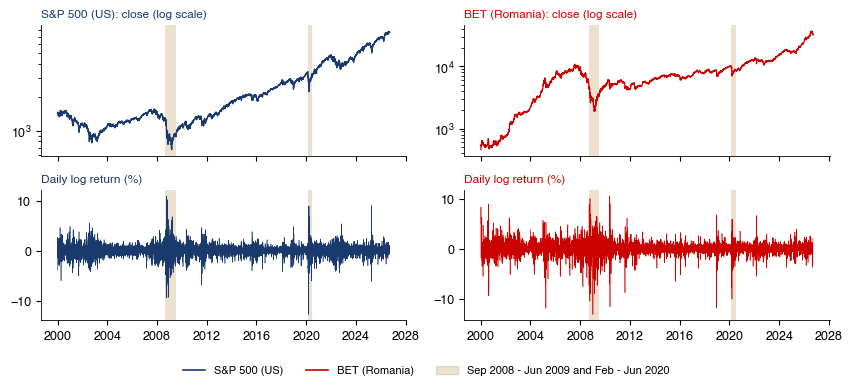

   saved ch2_sem_data
A1 {'mean': np.float64(0.1875), 'var1': np.float64(0.55859375), 'sums': array([ 0.5,  0.3,  1.1, -0.9, -0.6,  1.5,  0.5]), 'varq': np.float64(0.6291964285714285), 'VR': np.float64(0.5631968031968032), 'rho': [np.float64(-0.39472027972027973)], 'approx': np.float64(0.6052797202797202)}


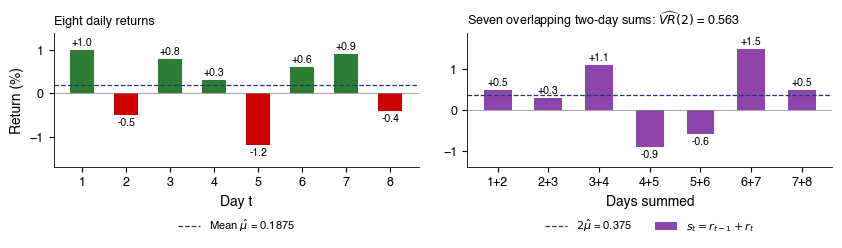

   saved ch2_sem_a1


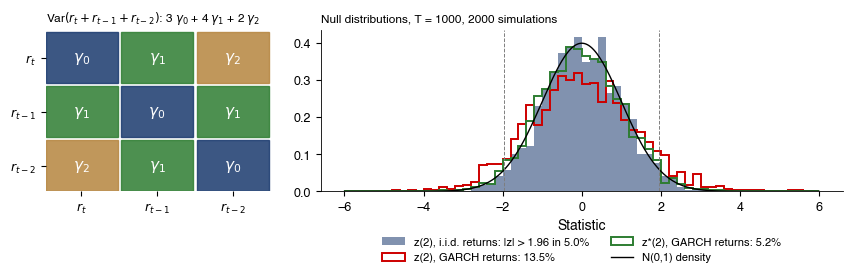

   saved ch2_sem_a2
A3 {'n1': 12, 'n2': 8, 'runs': 11, 'mean': 10.6, 'var': 4.3452631578947365, 'z': np.float64(0.1918898262711097), 'p': np.float64(0.8478285068142399)}


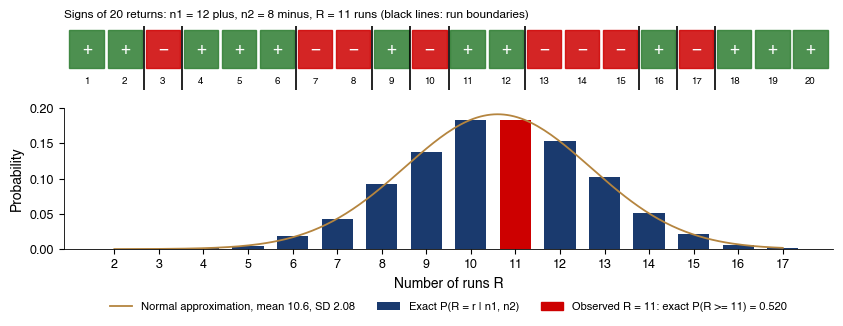

   saved ch2_sem_a3


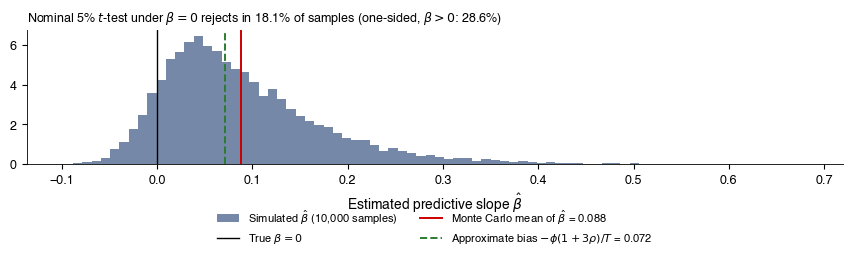

   saved ch2_sem_a4
                  N    VR2     z2  zstar2    VR5     z5  zstar5   VR10    z10  \
market                                                                          
S&P 500 (US)   6714  0.901 -8.120  -3.644  0.830 -6.375  -2.772  0.767 -5.654   
BET (Romania)  6670  1.108  8.827   3.836  1.173  6.445   2.980  1.225  5.444   

               zstar10   VR20    z20  zstar20     CD   CD_p  
market                                                       
S&P 500 (US)    -2.497  0.753 -4.064   -1.856  3.644  0.001  
BET (Romania)    2.732  1.377  6.195    3.311  3.836  0.001  
{'T': 6714, 'mu': np.float64(0.024718705886760773), 'var_a': np.float64(1.4714407863451455), 'm': 13422.000595770032, 'var_c': np.float64(1.3256258484524974), 'VR': np.float64(0.9009032920347192), 'delta1': np.float64(4.9659223611477925), 'theta': np.float64(4.9659223611477925), 'z': np.float64(-8.119885322677899), 'zstar': np.float64(-3.64376141841356), 'p': np.float64(0.0002686824906008578), 'n_sums': 

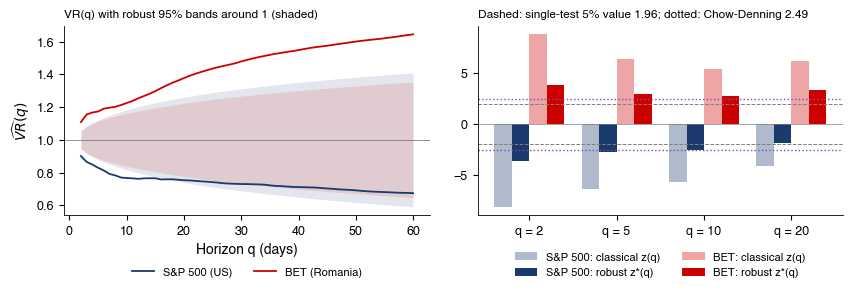

   saved ch2_sem_b1


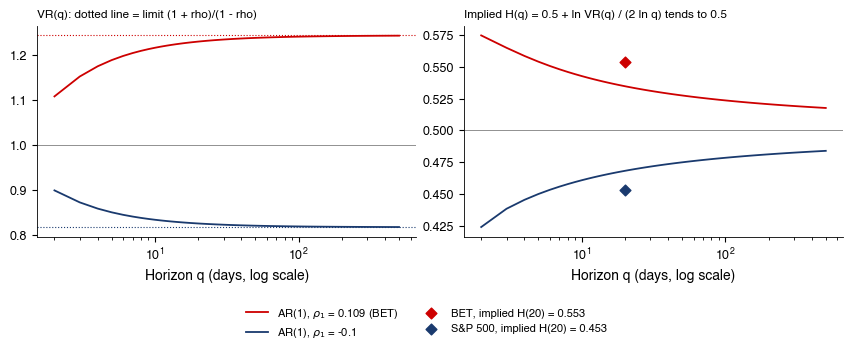

   saved ch2_sem_a56
                      N    VR2     z2  zstar2    VR5     z5  zstar5   VR10  \
market                                                                       
BET-TR (Romania)   2992  1.061  3.326   1.594  1.209  5.216   2.398  1.217   
WIG20 (Poland)     6685  1.018  1.469   1.010  1.009  0.343   0.241  1.002   
BUX (Hungary)      6666  1.037  3.008   1.514  1.013  0.493   0.257  1.009   
PX (Czechia)       6682  1.052  4.215   1.634  1.041  1.527   0.592  1.069   
BIST 100 (Turkey)  6692  1.005  0.386   0.198  1.033  1.215   0.637  1.003   
Bovespa (Brazil)   6622  0.971 -2.385  -1.181  0.928 -2.676  -1.285  0.885   
IPC (Mexico)       6689  1.068  5.597   3.683  1.039  1.453   0.926  0.982   
Nifty 50 (India)   6606  1.048  3.938   1.978  1.048  1.780   0.915  1.046   
Shanghai (China)   6474  1.021  1.715   1.120  1.046  1.691   1.108  1.062   

                     z10  zstar10   VR20    z20  zstar20     CD   CD_p  
market                                         

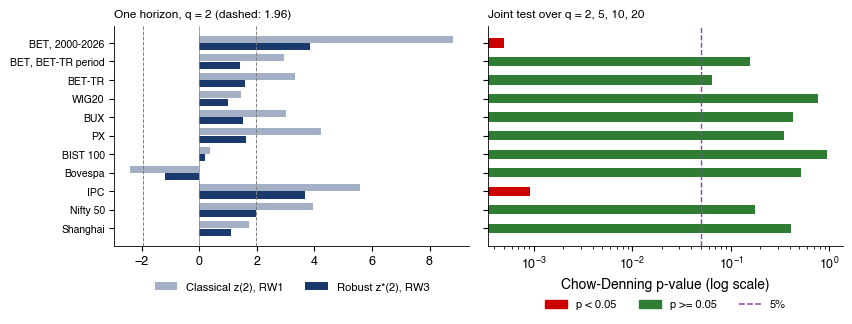

   saved ch2_sem_b2


B3 {'lo_t': np.float64(0.3778242224128016), 'hi_t': np.float64(0.6143493884737028), 'share_t': 0.06418918918918919, 'share_out': 0.02027027027027027, 'n': 296, 'band_lo_mean': 0.3587853560649089, 'band_hi_mean': 0.6438014682118395, 'width_min': 0.2075445909344527, 'width_max': 0.49998510845667354, 'argwide': datetime.date(2022, 2, 11), 'min': 0.34072667671889256, 'max': 0.5978900709448012, 'argmin': datetime.date(2022, 3, 15), 'argmax': datetime.date(2021, 2, 12), 'mean': np.float64(0.4501423601066471)}


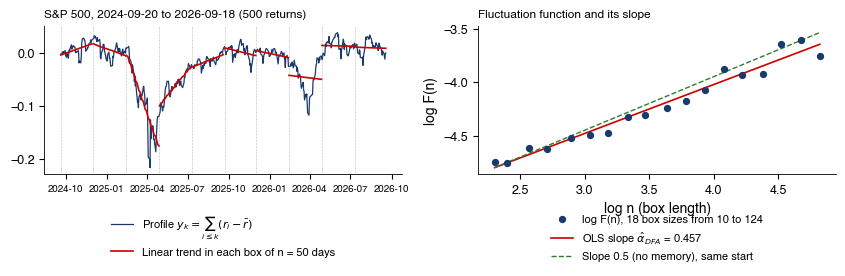

   saved ch2_sem_b3_window


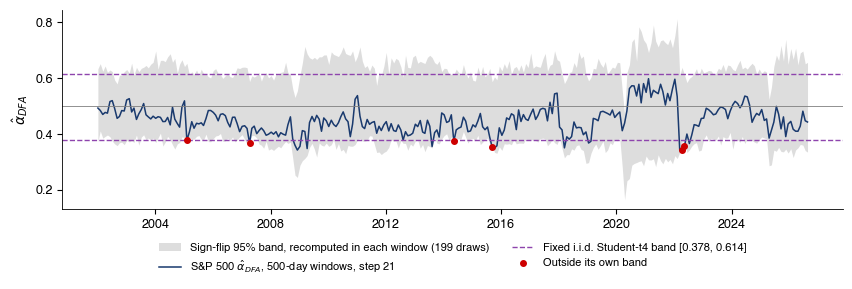

   saved ch2_sem_b3_rolling


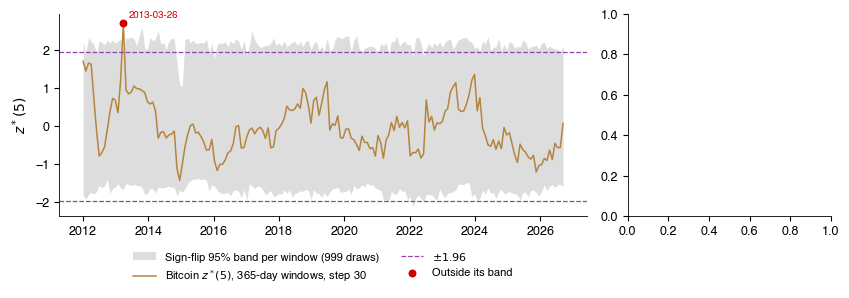

   saved ch2_sem_amh_btc
B4 reject share 0.005555555555555556
B5 {'sp500': {'N': 6701, 'share_tom': 0.19101626622892107, 'const': 1.8649977955817918, 'beta': 3.2384855452832775, 'se_ols': 3.772269692711653, 't_ols': 0.8584978829960933, 'se_hac': 3.4935359643518895, 't_hac': 0.926993618594126, 'p_hac': 0.3539298475525614, 'mean_tom': 5.103483340865002, 'mean_other': 1.86499779558181}, 'bet': {'N': 6656, 'share_tom': 0.19230769230769232, 'const': 3.119561784623337, 'beta': 17.324122077308147, 'se_ols': 4.345035030803633, 't_ols': 3.9871075732395136, 'se_hac': 4.781317924620495, 't_hac': 3.6232943197733927, 'p_hac': 0.00029087451944493953, 'mean_tom': 20.44368386193187, 'mean_other': 3.1195617846232304}}


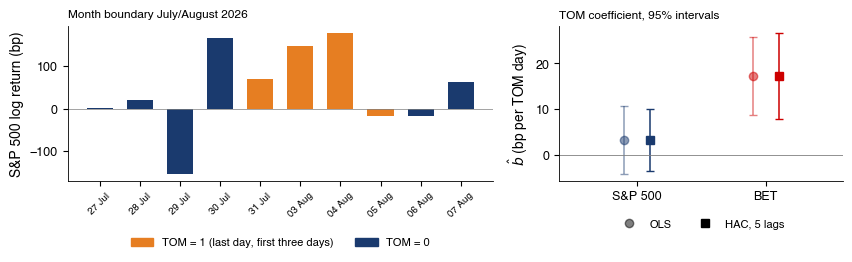

   saved ch2_sem_b5
            market                     effect       p  bonferroni_reject  \
0     S&P 500 (US)  day of week (equal means)  0.8263              False   
1     S&P 500 (US)                    January  0.4257              False   
2     S&P 500 (US)              turn of month  0.3539              False   
3    BET (Romania)  day of week (equal means)  0.3052              False   
4    BET (Romania)                    January  0.1368              False   
5    BET (Romania)              turn of month  0.0003               True   
6    Euro Stoxx 50  day of week (equal means)  0.6319              False   
7    Euro Stoxx 50                    January  0.7738              False   
8    Euro Stoxx 50              turn of month  0.2266              False   
9   WIG20 (Poland)  day of week (equal means)  0.2262              False   
10  WIG20 (Poland)                    January  0.6865              False   
11  WIG20 (Poland)              turn of month  0.0841              F

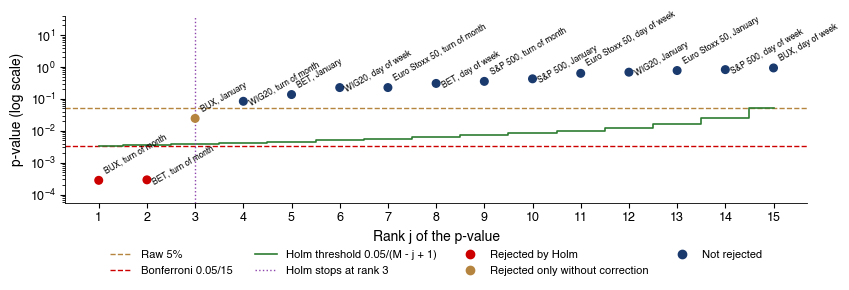

   saved ch2_sem_b6
                                      N   rho1  t_iid  t_robust  zstar5  \
all days                         6714.0 -0.099 -8.078    -3.625  -2.772   
without 2008-09 and 2020 crises  6411.0 -0.043 -3.408    -2.342  -2.633   

                                 n_pairs  n_windows  
all days                          6713.0     6710.0  
without 2008-09 and 2020 crises   6408.0     6399.0  


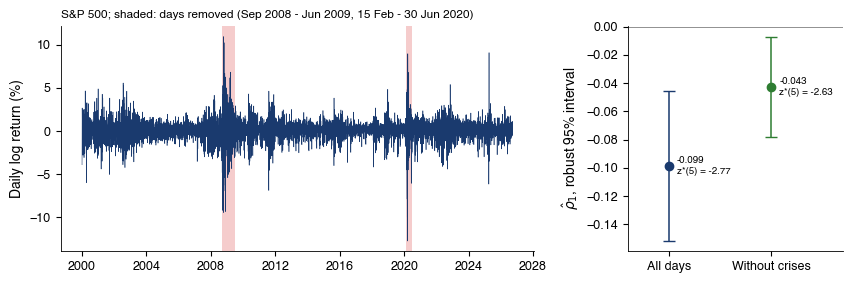

   saved ch2_sem_b7


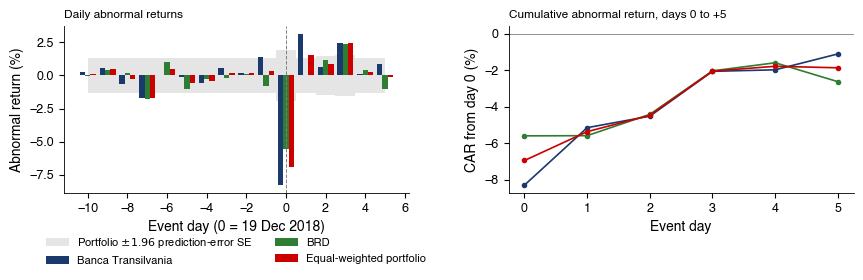

   saved ch2_sem_b9


C1 {'bet': {'before': (datetime.date(2015, 9, 21), datetime.date(2020, 9, 18), 1249, np.float64(-0.001901256184784491), np.float64(0.799464763433614)), 'after': (datetime.date(2020, 9, 21), datetime.date(2025, 9, 19), 1248, np.float64(0.08741023337099922), np.float64(1.776953356050492)), 'diff': np.float64(0.08931148955578372), 'ci': (np.float64(-0.03114745013041411), np.float64(0.19393184918003217)), 'se_before': np.float64(0.0666379766425199), 'se_after': np.float64(0.04609702546989548)}, 'wig20': {'before': (datetime.date(2015, 9, 21), datetime.date(2020, 9, 18), 1248, np.float64(0.03920444322354739), np.float64(0.7332674322685291)), 'after': (datetime.date(2020, 9, 21), datetime.date(2025, 9, 19), 1251, np.float64(-0.03615341945923217), np.float64(-0.8366590436264594)), 'diff': np.float64(-0.07535786268277955), 'ci': (np.float64(-0.18072875160250626), np.float64(0.03586199898818493)), 'se_before': np.float64(0.05960889968993546), 'se_after': np.float64(0.04653436342331823)}, 'bux':

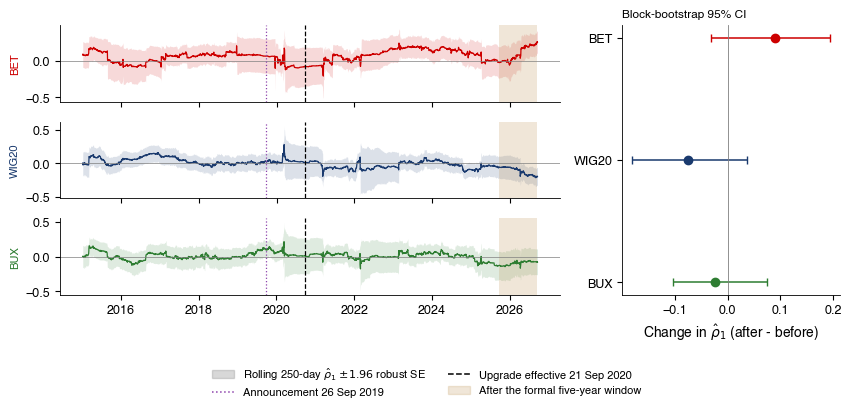

   saved ch2_sem_c1


In [7]:
print(setup_check())
fig_sem_data()
a1 = a_vr_by_hand()
print('A1', a1)
fig_a1(a1)
sim = a2_null()
fig_a2(sim)
ex = a_runs()
print('A3', ex)
fig_a3(a3_exact(ex['n1'], ex['n2'], ex['runs']), ex)
a4 = a4_sim()
fig_a4(a4, -0.9 * 0.17 / 0.14 * (-(1 + 3 * 0.98) / 60))
t = b_vr_table(['sp500', 'bet'])
print(t.round(3))
print(b1_worked('sp500', 2))
fig_b1(t)
rho_bet = float(log_returns('bet').autocorr(1))
fig_a56(rho_bet, -0.1, h_from_vr(t.loc[LABELS['bet'], 'VR20'], 20), h_from_vr(t.loc[LABELS['sp500'], 'VR20'], 20))
t2 = b_vr_table(['bettr', 'wig20', 'bux', 'px', 'xu100', 'bvsp', 'mxx', 'nsei', 'ssec'])
print(t2.round(3))
b2c = b_bet_common_period()
fig_b2(t2, t, b2c)
print('B3', b_rolling_dfa())
fig_b3_window(b3_window())
fig_b3_rolling(pd.read_csv('ch2_sem_rolling_dfa.csv', index_col=0, parse_dates=True), 0.3778, 0.6143)
d = b_amh_bitcoin()
fig_amh_btc(d)
print('B4 reject share', d['reject'].mean())
res = {k: b_tom_ols_hac(k) for k in ['sp500', 'bet']}
print('B5', res)
fig_b5(b5_strip(), res)
cm = b_calendar_multiple(calendar_table())
print(cm.round(4))
fig_b6(cm)
b7 = b_crisis_robustness()
print(b7.round(3))
fig_b7(b7.to_dict(orient='index'))
fig_b9(b9_event_path())
c1 = {k: c_bvb_before_after(k=k) for k in ['bet', 'wig20', 'bux']}
print('C1', c1)
fig_c1(c1_rolling(), c1)

![ch2_sem_data](./ch2_sem_data.png)

Output: `ch2_sem_data.pdf`

![ch2_sem_a1](./ch2_sem_a1.png)

Output: `ch2_sem_a1.pdf`

![ch2_sem_a2](./ch2_sem_a2.png)

Output: `ch2_sem_a2.pdf`

![ch2_sem_a3](./ch2_sem_a3.png)

Output: `ch2_sem_a3.pdf`

![ch2_sem_a4](./ch2_sem_a4.png)

Output: `ch2_sem_a4.pdf`

![ch2_sem_a56](./ch2_sem_a56.png)

Output: `ch2_sem_a56.pdf`

![ch2_sem_b1](./ch2_sem_b1.png)

Output: `ch2_sem_b1.pdf`

![ch2_sem_b2](./ch2_sem_b2.png)

Output: `ch2_sem_b2.pdf`

![ch2_sem_b3_window](./ch2_sem_b3_window.png)

Output: `ch2_sem_b3_window.pdf`

![ch2_sem_b3_rolling](./ch2_sem_b3_rolling.png)

Output: `ch2_sem_b3_rolling.pdf`

![ch2_sem_amh_btc](./ch2_sem_amh_btc.png)

Output: `ch2_sem_amh_btc.pdf`

![ch2_sem_b5](./ch2_sem_b5.png)

Output: `ch2_sem_b5.pdf`

![ch2_sem_b6](./ch2_sem_b6.png)

Output: `ch2_sem_b6.pdf`

![ch2_sem_b7](./ch2_sem_b7.png)

Output: `ch2_sem_b7.pdf`

![ch2_sem_b8](./ch2_sem_b8.png)

Output: `ch2_sem_b8.pdf`

![ch2_sem_b9](./ch2_sem_b9.png)

Output: `ch2_sem_b9.pdf`

![ch2_sem_c1](./ch2_sem_c1.png)

Output: `ch2_sem_c1.pdf`